## Gaussian density modification
$$R(z) = re^{-\alpha z^2/2}$$

In [145]:
import numpy as np
from scipy.integrate import solve_ivp

# Define the system of ODEs
def system(t, z):
    x, y = z
    dxdt = x + y
    dydt = y - x
    return [dxdt, dydt]

# Event function: stop if either x or y exceeds 10
def stop_event(t, z):
    x, y = z
    return max(x, y) - 10  # Triggers when either x or y reaches 10

# Ensure the event is terminal
stop_event.terminal = True

# Initial conditions and time span
t_span = [0, 5]
z0 = [1, 2]  # Initial (x, y)

# Solve the system
sol = solve_ivp(system, t_span, z0, events=stop_event)

# Print results
print("Solution times:", sol.t)
print("Solution values (x, y):", sol.y)
print("Stopped at t =", sol.t_events[0])

Solution times: [0.         0.08074997 0.72419858 1.51528281 2.38784058 3.18162492
 4.04379486 4.3085105 ]
Solution values (x, y): [[   1.            1.2554591     4.27874551    9.33732313    6.95745156
   -25.9842532  -124.75330408 -165.69591571]
 [   2.            2.07368859    1.72368629   -4.03796751  -23.32066242
   -47.12634026  -25.88754059   10.        ]]
Stopped at t = [4.3085105]


In [7]:
start_angle = 0
stop_angle = 2*np.pi

num = 128
angles = np.linspace(start_angle, stop_angle, num)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))
sigma_vals[1]

(2.996329248642784+0.14836115976821698j)

In [ ]:
from scipy.integrate import solve_ivp
import numpy as np


from numba import jit

# @jit
def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    directions_num = 2
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    mass_modification = kwargs.get("mass_modification", 5)

    def stop_event(t, z, *args, **kwargs):
        x, y = z
        return max(x, y) - 10  # Triggers when either x or y reaches 10

    # Ensure the event is terminal
    stop_event.terminal = True

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, mass_modification), t_eval=t_eval, method="BDF", events=stop_event)
        sol.append(solution.y[0] + 1j * solution.y[1])
    return sol


# @jit
def drift_func(z, sigma, lamb, pullback, mass_modification):
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        return drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        return drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)

drift_func = np.vectorize(drift_func)

# @jit
def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

# @jit
def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

0


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37939/3691578584.py:113: RuntimeWarning: overflow encountered in power
  action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37939/3691578584.py:113: RuntimeWarning: invalid value encountered in power
  action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37939/3691578584.py:113: RuntimeWarning: invalid value encountered in scalar multiply
  action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)


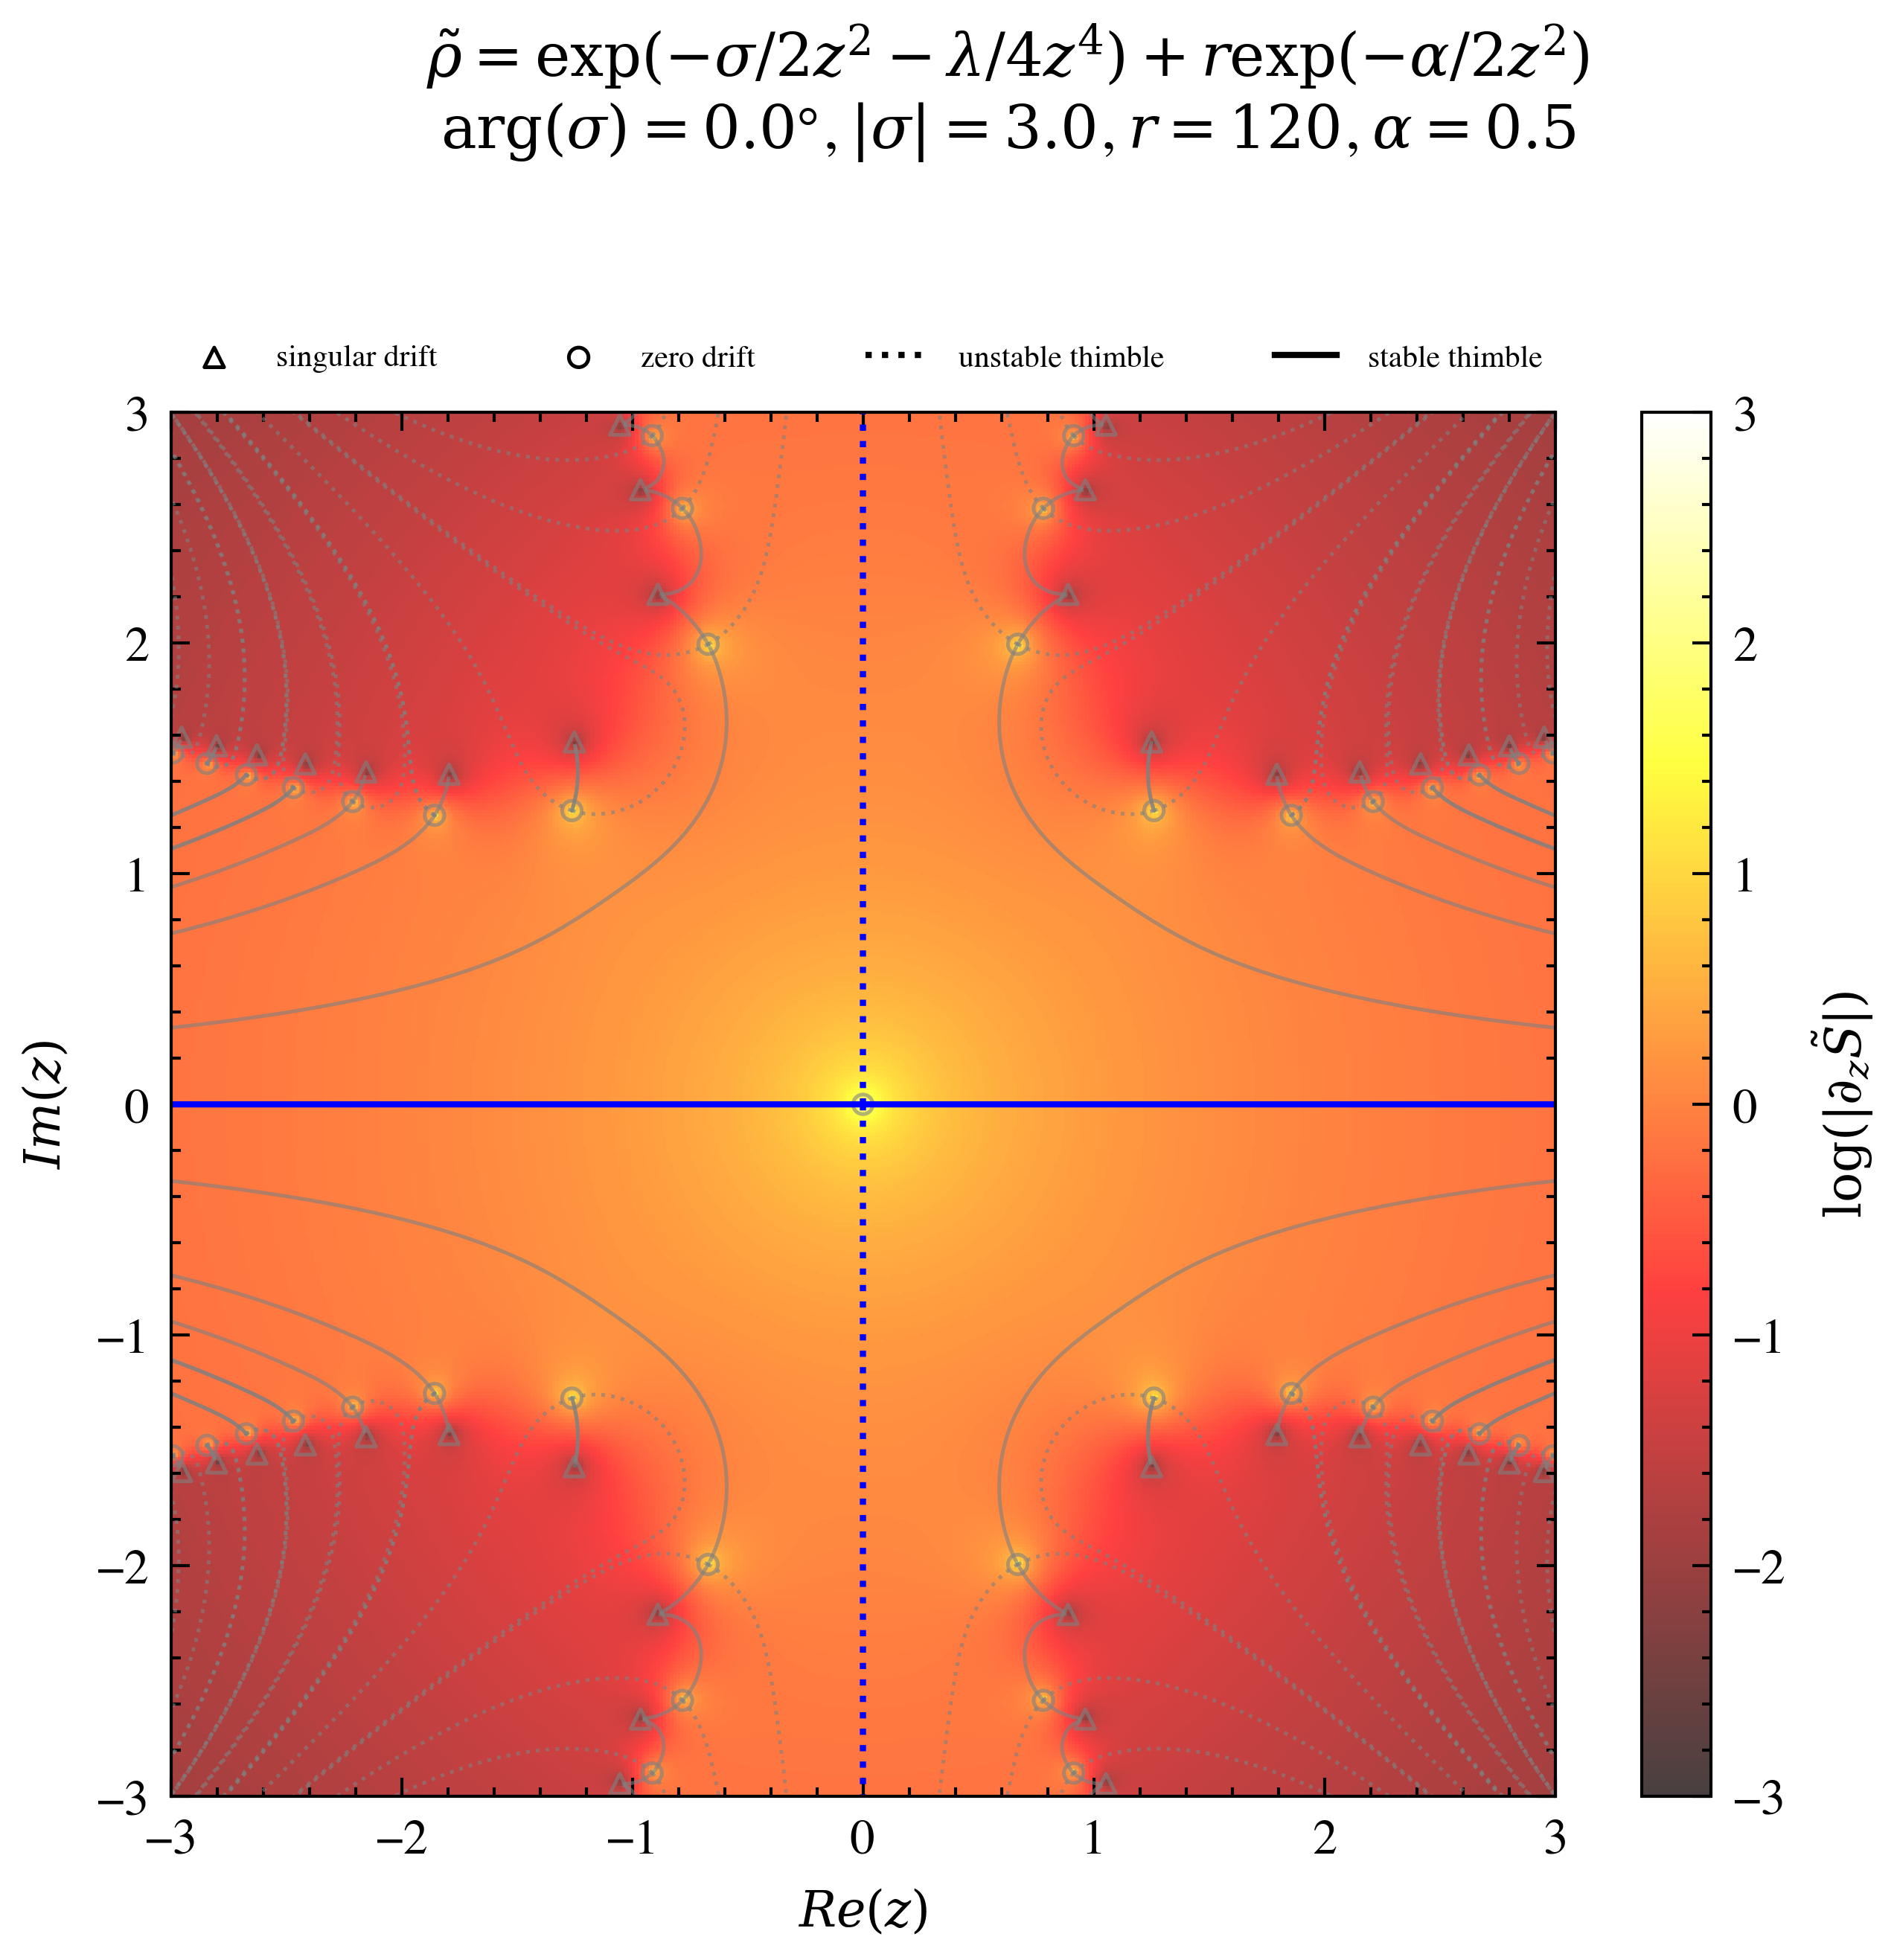

In [2]:
from scipy.integrate import solve_ivp
import numpy as np


from numba import jit

# @jit
def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    directions_num = 2
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    mass_modification = kwargs.get("mass_modification", 5)

    def stop_event(t, z, *args, **kwargs):
        x, y = z
        return max(x, y) - 10  # Triggers when either x or y reaches 10

    # Ensure the event is terminal
    stop_event.terminal = True

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, mass_modification), t_eval=t_eval, method="BDF", events=stop_event)
        sol.append(solution.y[0] + 1j * solution.y[1])
    return sol


# @jit
def drift_func(z, sigma, lamb, pullback, mass_modification):
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        return drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        return drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)

drift_func = np.vectorize(drift_func)

# @jit
def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

# @jit
def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]





lamb = 1
sigma_abs = 3

start_angle = 0
stop_angle = 2*np.pi

num = 1
angles = np.linspace(start_angle, stop_angle, num)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

mass_modification = 0.5
pullback = 120

import matplotlib.pyplot as plt
from scipy.optimize import root
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams["text.usetex"] = False  # Disable LaTeX rendering

def F_real(z_real):
    z = z_real[0] + 1j * z_real[1]
    Fz = F(z)
    return np.array([Fz.real, Fz.imag])

import time

for idx_sig, sigma in enumerate(sigma_vals):
    print(idx_sig)
    t_final = time.time()
    x_range = (-3, 3)
    y_range = (-3, 3)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    deg = np.degrees(np.angle(sigma))
    fig.suptitle(rf"$\tilde{{\rho}} = \exp(-\sigma/2z^2-\lambda/4z^4) + r \exp(-\alpha/2z^2)$"+"\n"\
                 rf"$\text{{arg}}(\sigma) = {{{np.round((deg+360)%360, 3)}}}$°, $|\sigma| = {{{np.round(np.abs(sigma), 3)}}}$, $r={{{np.round(pullback, 3)}}}$"+\
                 rf", $\alpha={{{mass_modification}}}$")

    # mark zeros
    # Define the function whose zeros we want to find
    @np.vectorize
    def F(z):
        action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)
        if np.real(action_mod+np.log(pullback+0j)) > 100:
            return mass_modification * z + ((sigma - mass_modification) * z + lamb * z**3)/pullback * np.exp(-action_mod)
        return mass_modification * z + ((sigma - mass_modification) * z + lamb * z**3) / (1 + pullback * np.exp(action_mod))
    
    x_vals = np.linspace(-5, 5, 50)  # Real part of z
    y_vals = np.linspace(-5, 5, 50)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]

    # Store found roots
    roots = []

    # Solve for each initial guess
    find_roots = 0
    solve_flow = 0
    im_show = 0
    for z0 in initial_guesses:
        t0 = time.time()
        sol = root(F_real, z0, method='hybr')
        find_roots += time.time() - t0

        if sol.success:
            root_found = sol.x[0] + 1j * sol.x[1]

            # Avoid duplicates (consider numerical precision)
            if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):

                roots.append(root_found)
                # stable
                t0 = time.time()
                solutions = solve_floweq(flow_equation_unstable, crit_point=root_found, t_span = (0, 50), t_points=100000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
                solve_flow += time.time() - t0
                
                relevant = False
                conc_sol = np.concatenate(solutions, axis = 0)
                if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True

                for sol in solutions:
                    if relevant:
                        ax.plot(sol.real, sol.imag, color = 'blue', ls = ':')  # Set transparency for better visibility
                    else: 
                        ax.plot(sol.real, sol.imag, color = 'gray', ls = ':', alpha=0.6, lw = 0.6)  # Set transparency for better visibility
    
                # stable
                t0 = time.time()                
                solutions = solve_floweq(flow_equation_stable, crit_point=root_found, t_span = (0, 50), t_points=100000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
                solve_flow += time.time() - t0
                for sol in solutions:
                    if relevant: 
                        ax.plot(sol.real, sol.imag, color = 'blue', ls = "solid")  # Set transparency for better visibility
                    else: 
                        ax.plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        

    roots = np.array(roots)

    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0
    t0 = time.time() 
    im = ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.75, vmin=-3, vmax=3)
    cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.805)
    cbar.ax.set_ylabel(rf'$\log(|\partial_z \tilde{{S}}|)$', rotation=90)
    im_show += time.time() - t0

    # x = np.linspace(*x_range, 35)
    # y = np.linspace(*y_range, 35)
    # X, Y = np.meshgrid(x, y)
    # Z = X + 1j * Y
    # drift_values = np.conj(drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification))
    
    # U = np.real(drift_values)
    # V = np.imag(drift_values)
    # mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    # ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)
    ax.scatter(roots.real, roots.imag, s=10, facecolors='none', edgecolors='gray', lw = 0.6, alpha = 0.6)

    # show singularities in drift
    roots = []
    for z0 in initial_guesses:
        sol = root(lambda x: 1/F_real(x), z0, method='hybr')
        if sol.success:
            root_found = sol.x[0] + 1j * sol.x[1]
            if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
                roots.append(root_found)
    roots = np.array(roots)
    ax.scatter(roots.real, roots.imag, s=10, facecolors='none', edgecolors='gray', marker="^", lw = 0.6, alpha = 0.6)

    ax.set_xlabel(rf"$Re(z)$")
    ax.set_ylabel(rf"$Im(z)$")

    ax.scatter([], [], s=10, facecolors='none', edgecolors='black', marker="^", lw = 0.6, label = "singular drift")
    ax.scatter([], [], s=10, facecolors='none', edgecolors='black', lw = 0.6, label = "zero drift")
    ax.plot([], [], color = 'black', ls = ':', label = "unstable thimble")
    ax.plot([], [], color = 'black', ls = 'solid', label = "stable thimble")

    ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), fontsize = 5, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=1)
    fig.savefig(f"animated_thimbles/gaussian_mod/{idx_sig}")

0


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37348/1030671501.py:45: RuntimeWarning: overflow encountered in power
  action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37348/1030671501.py:45: RuntimeWarning: invalid value encountered in power
  action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37348/1030671501.py:45: RuntimeWarning: invalid value encountered in scalar multiply
  action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)


1
2
3
4
5


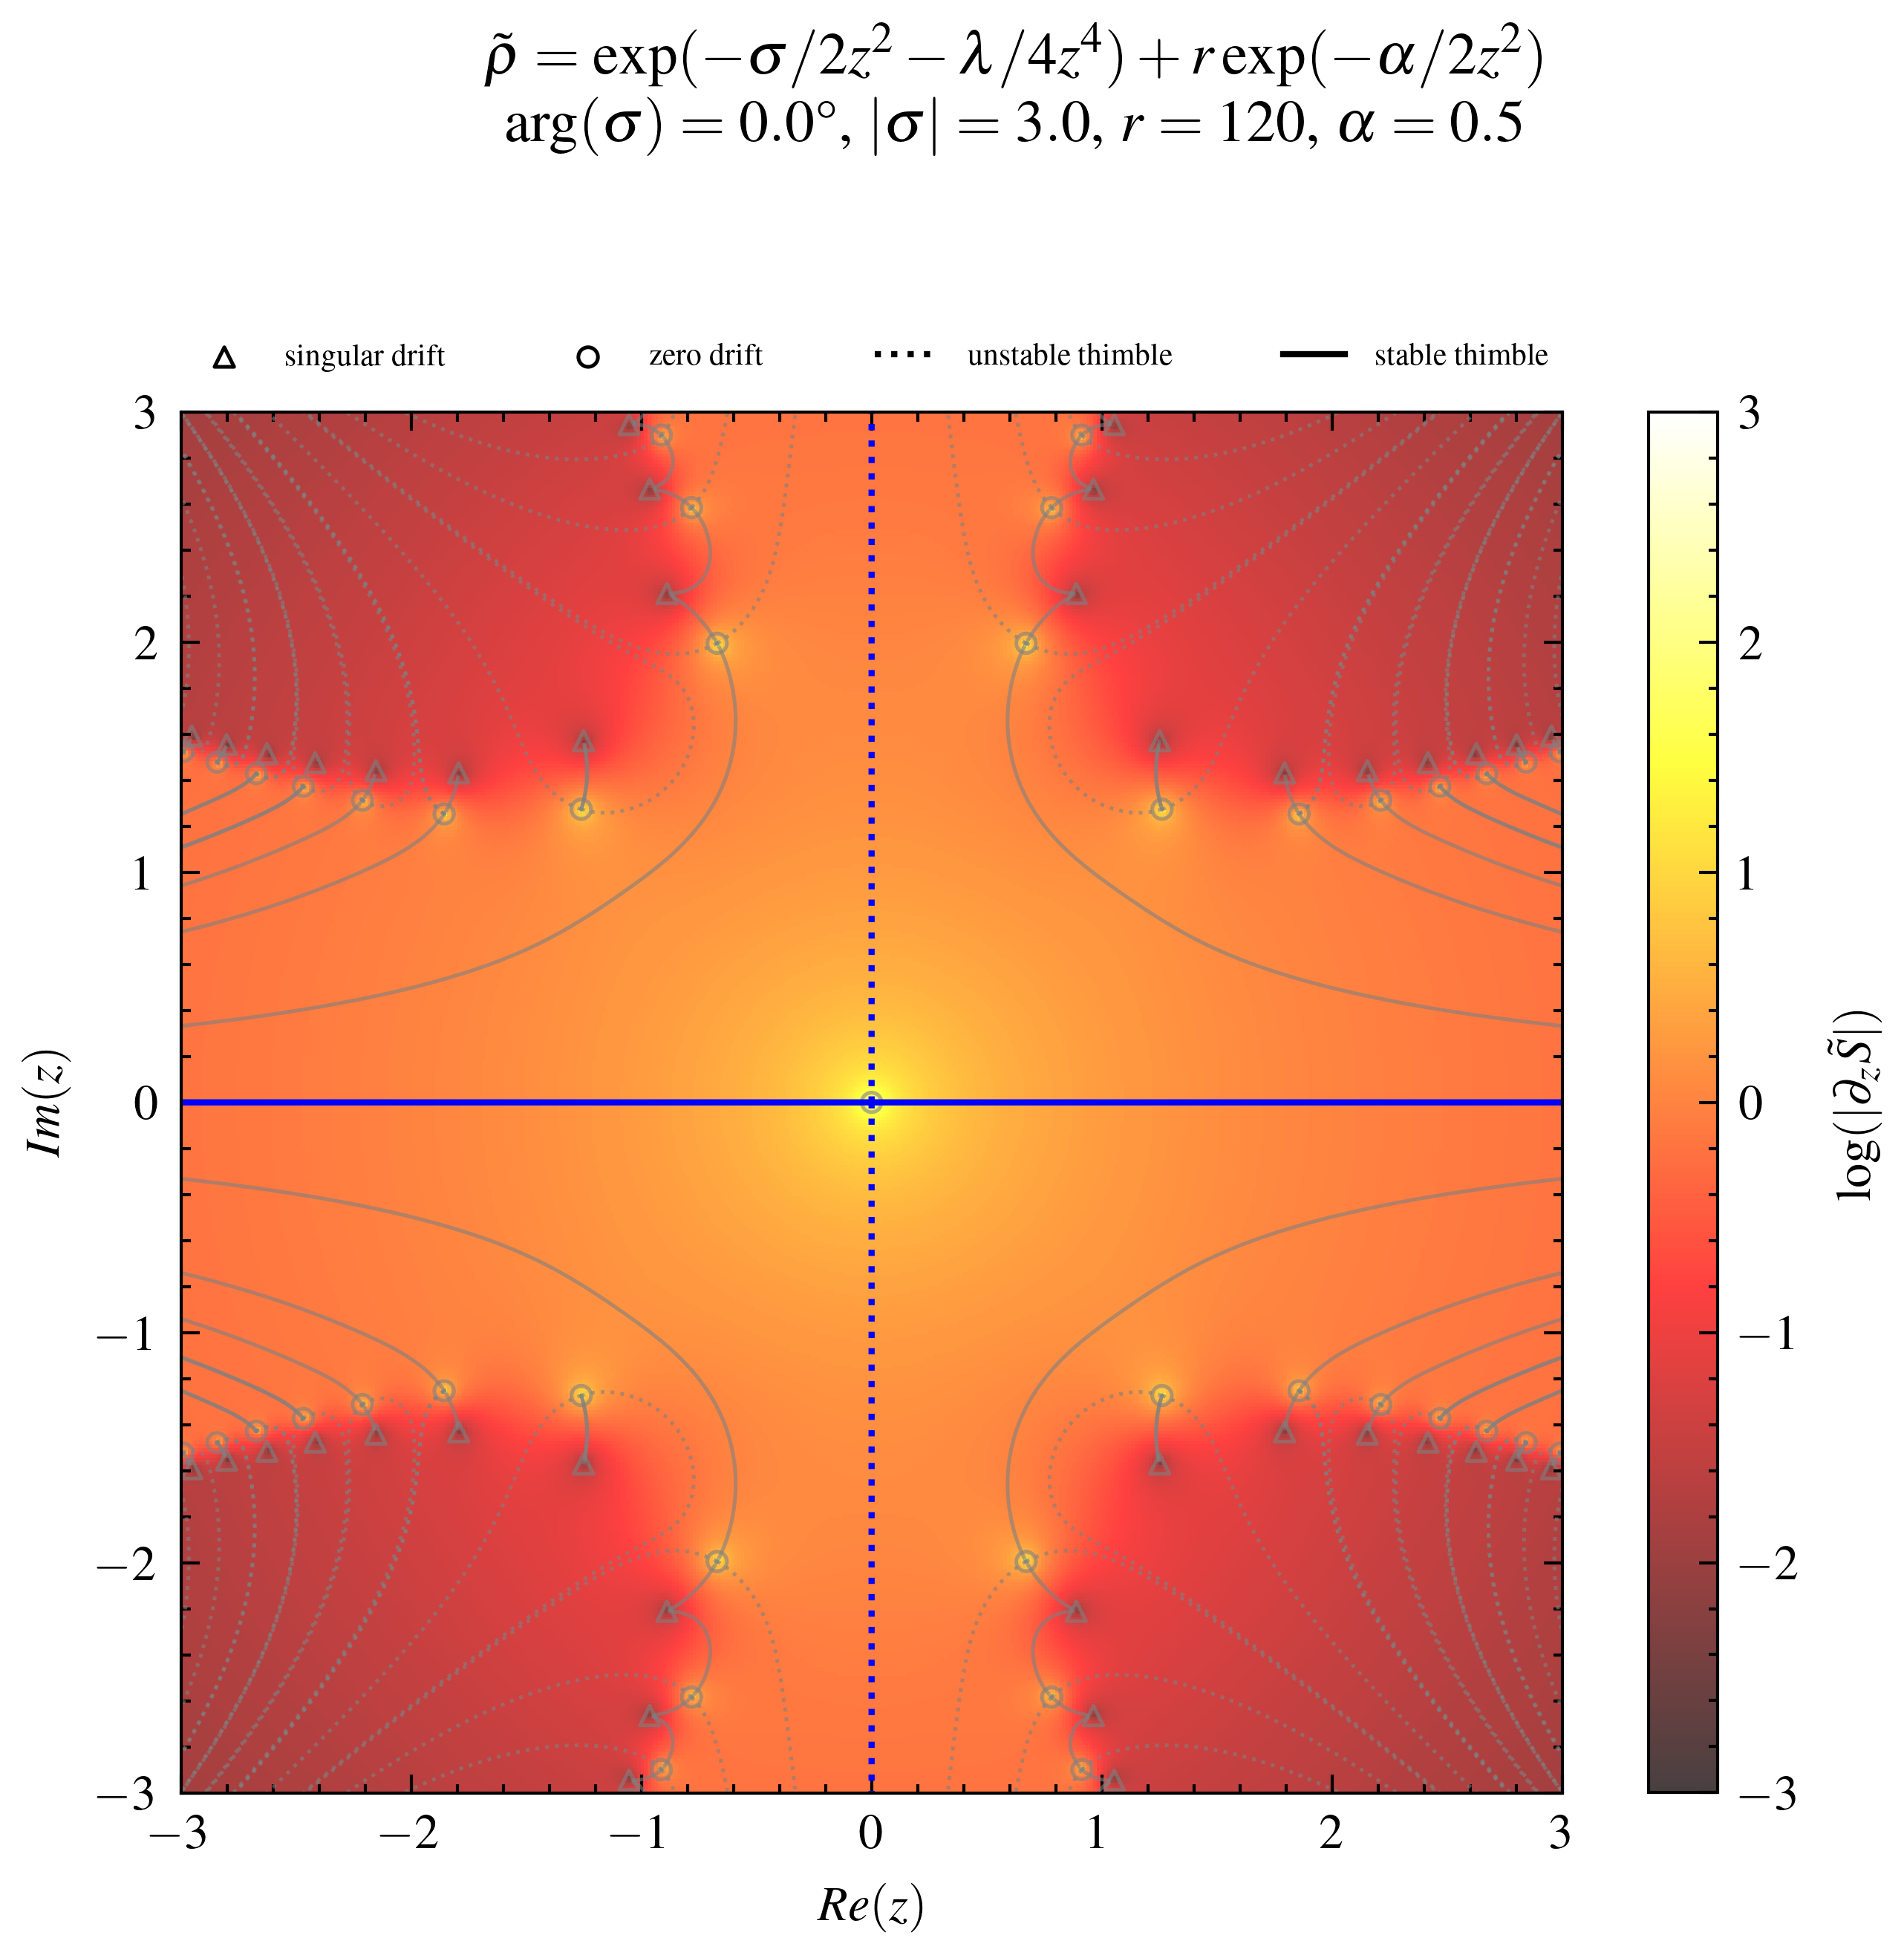

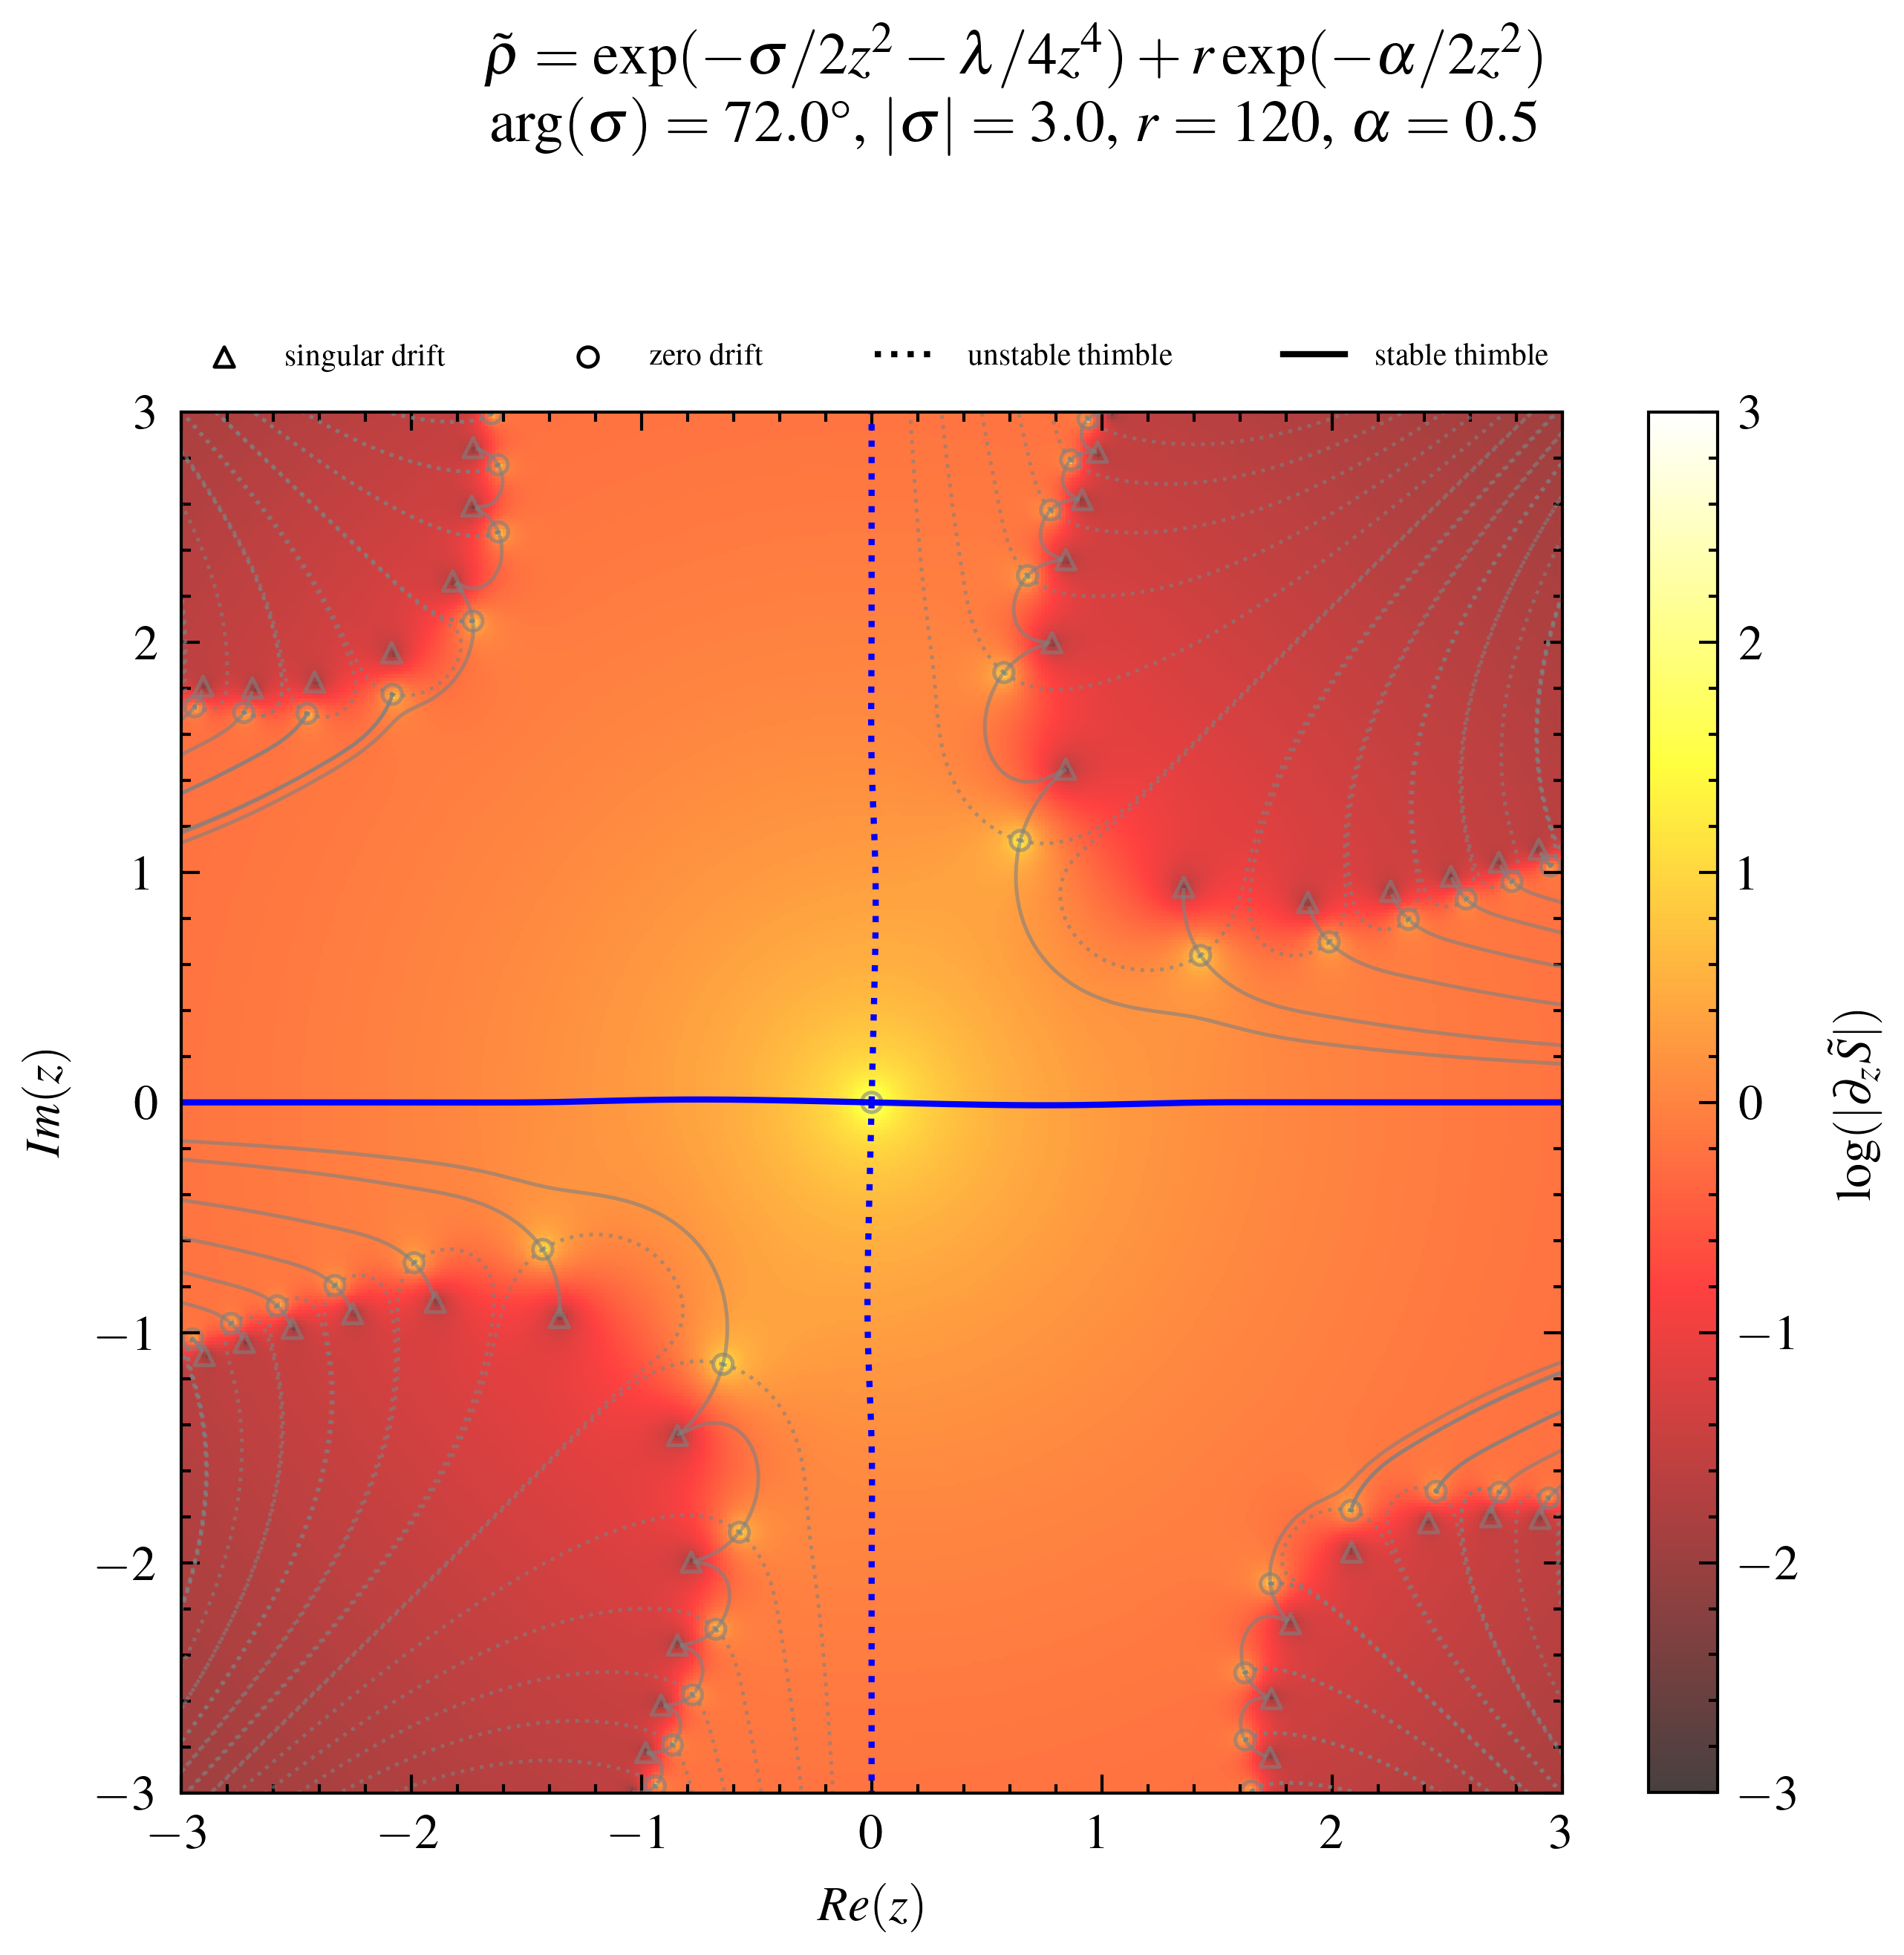

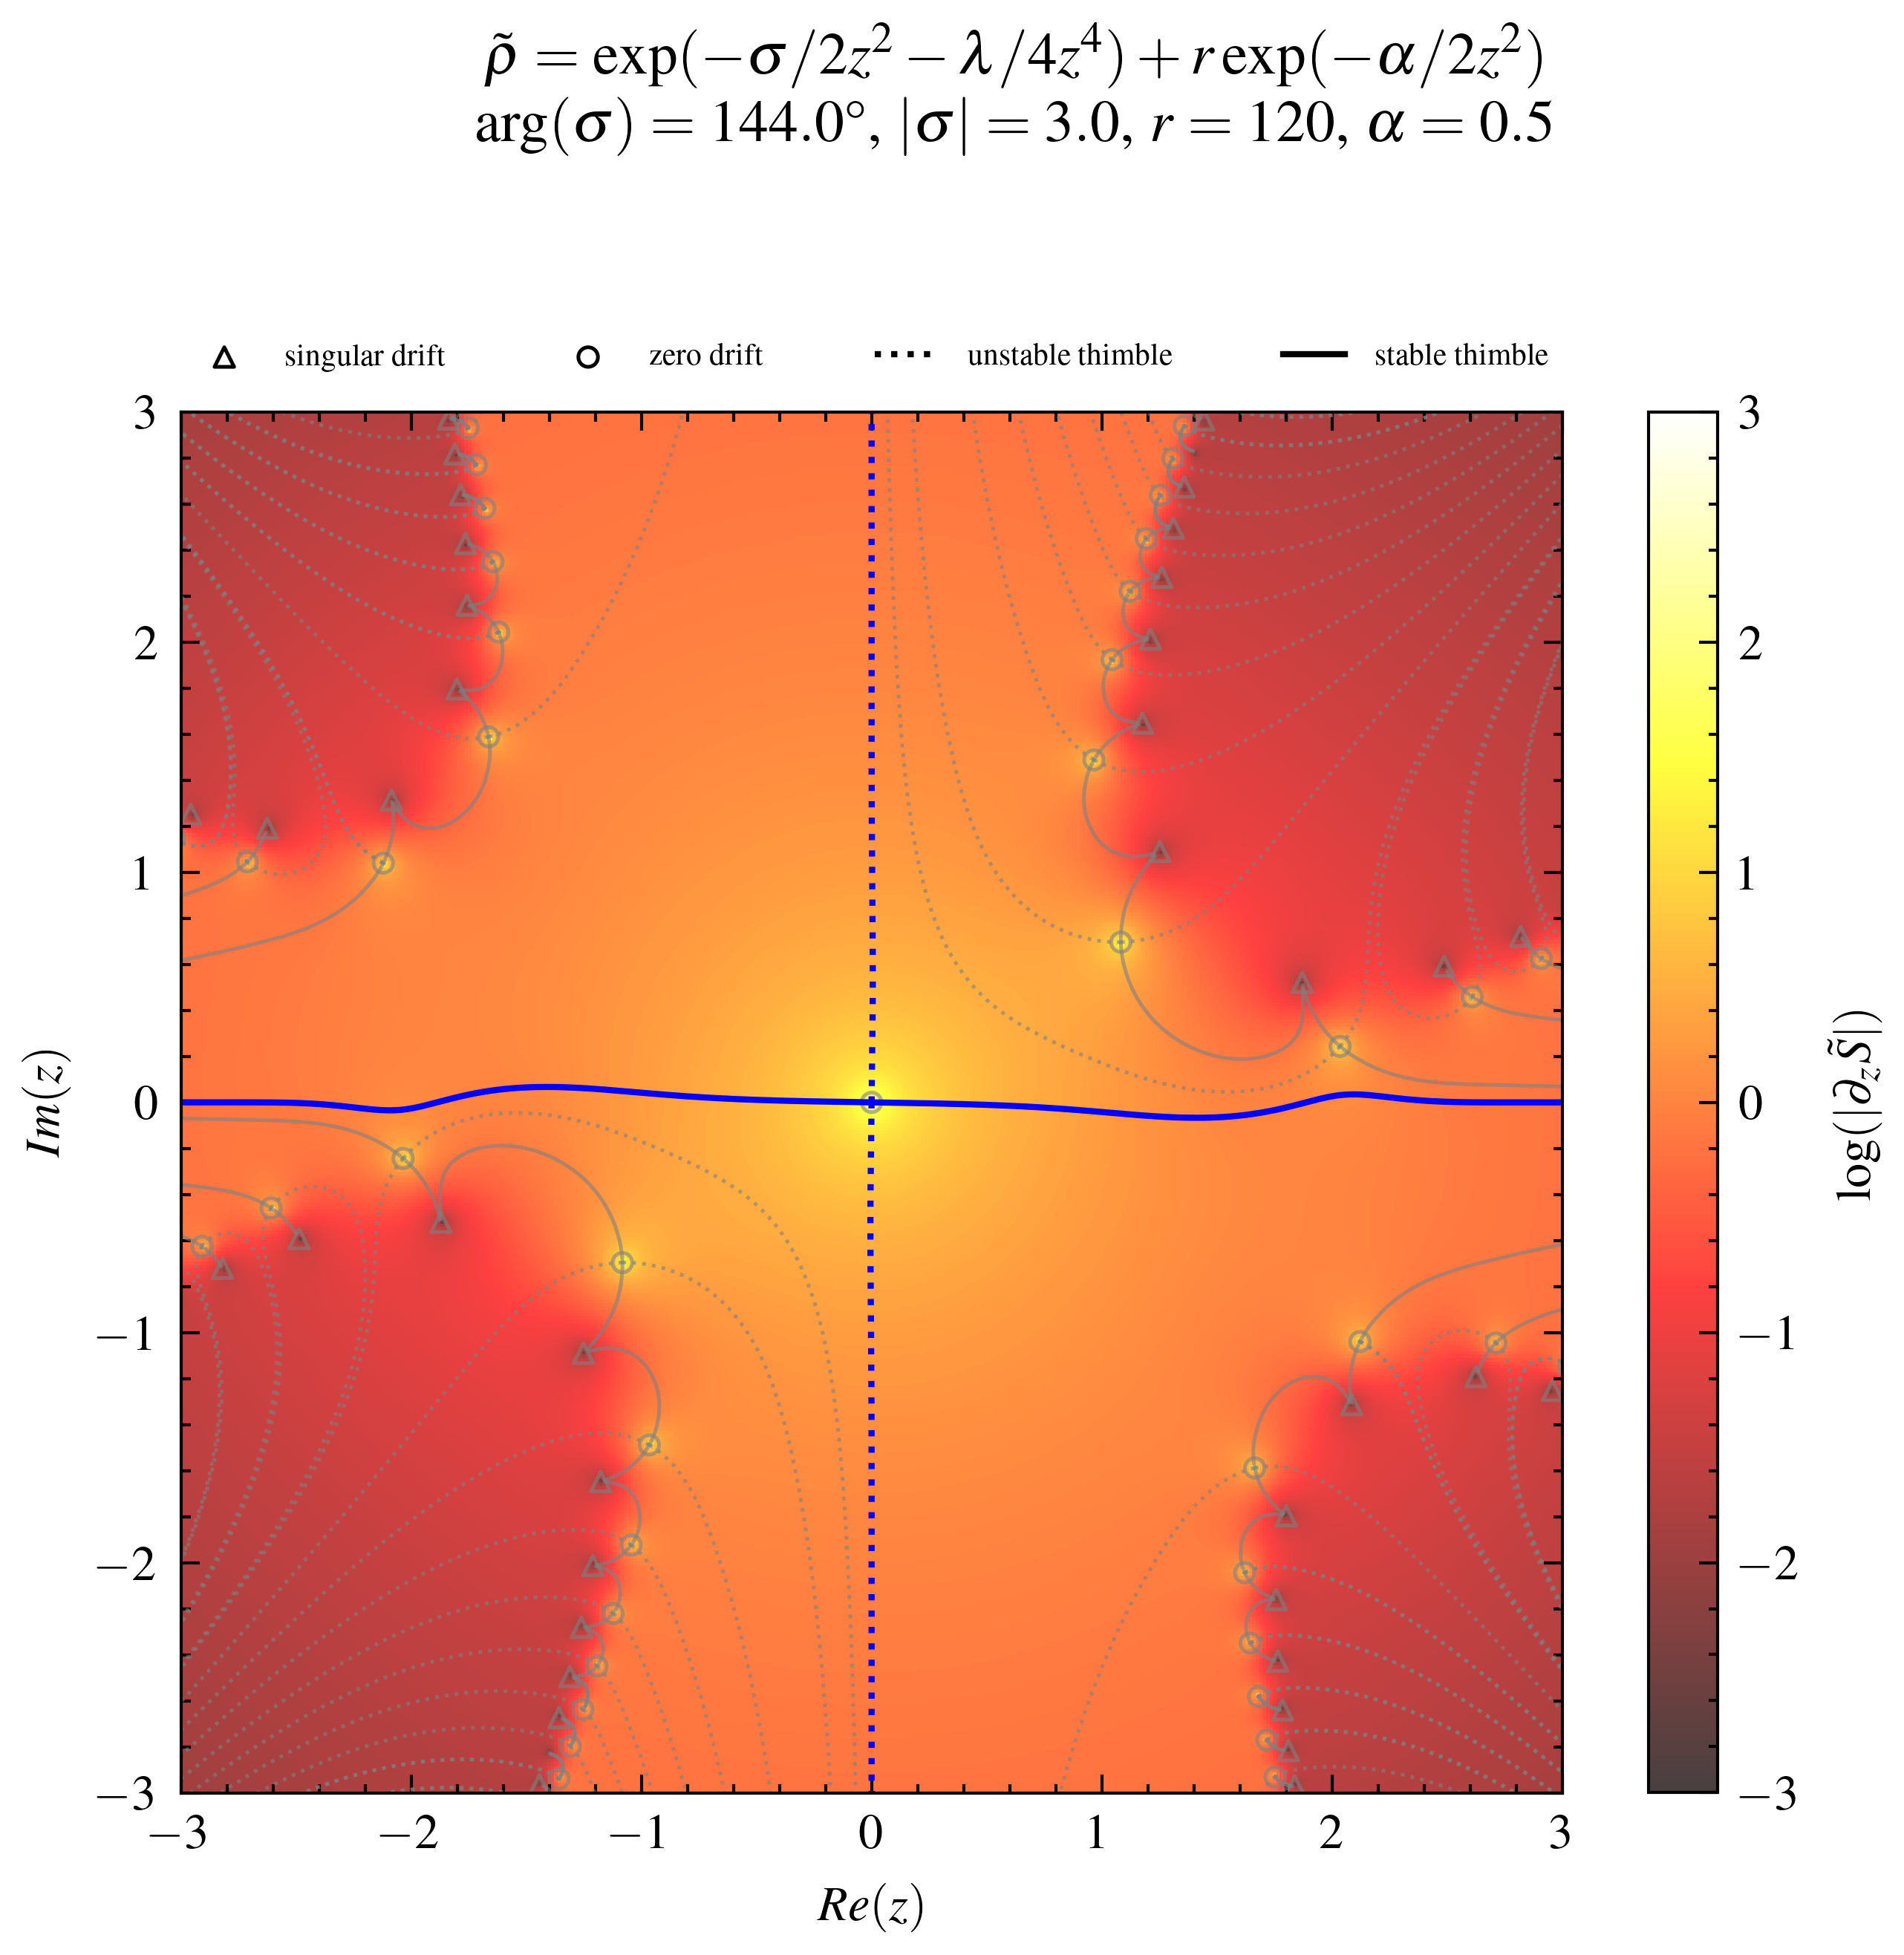

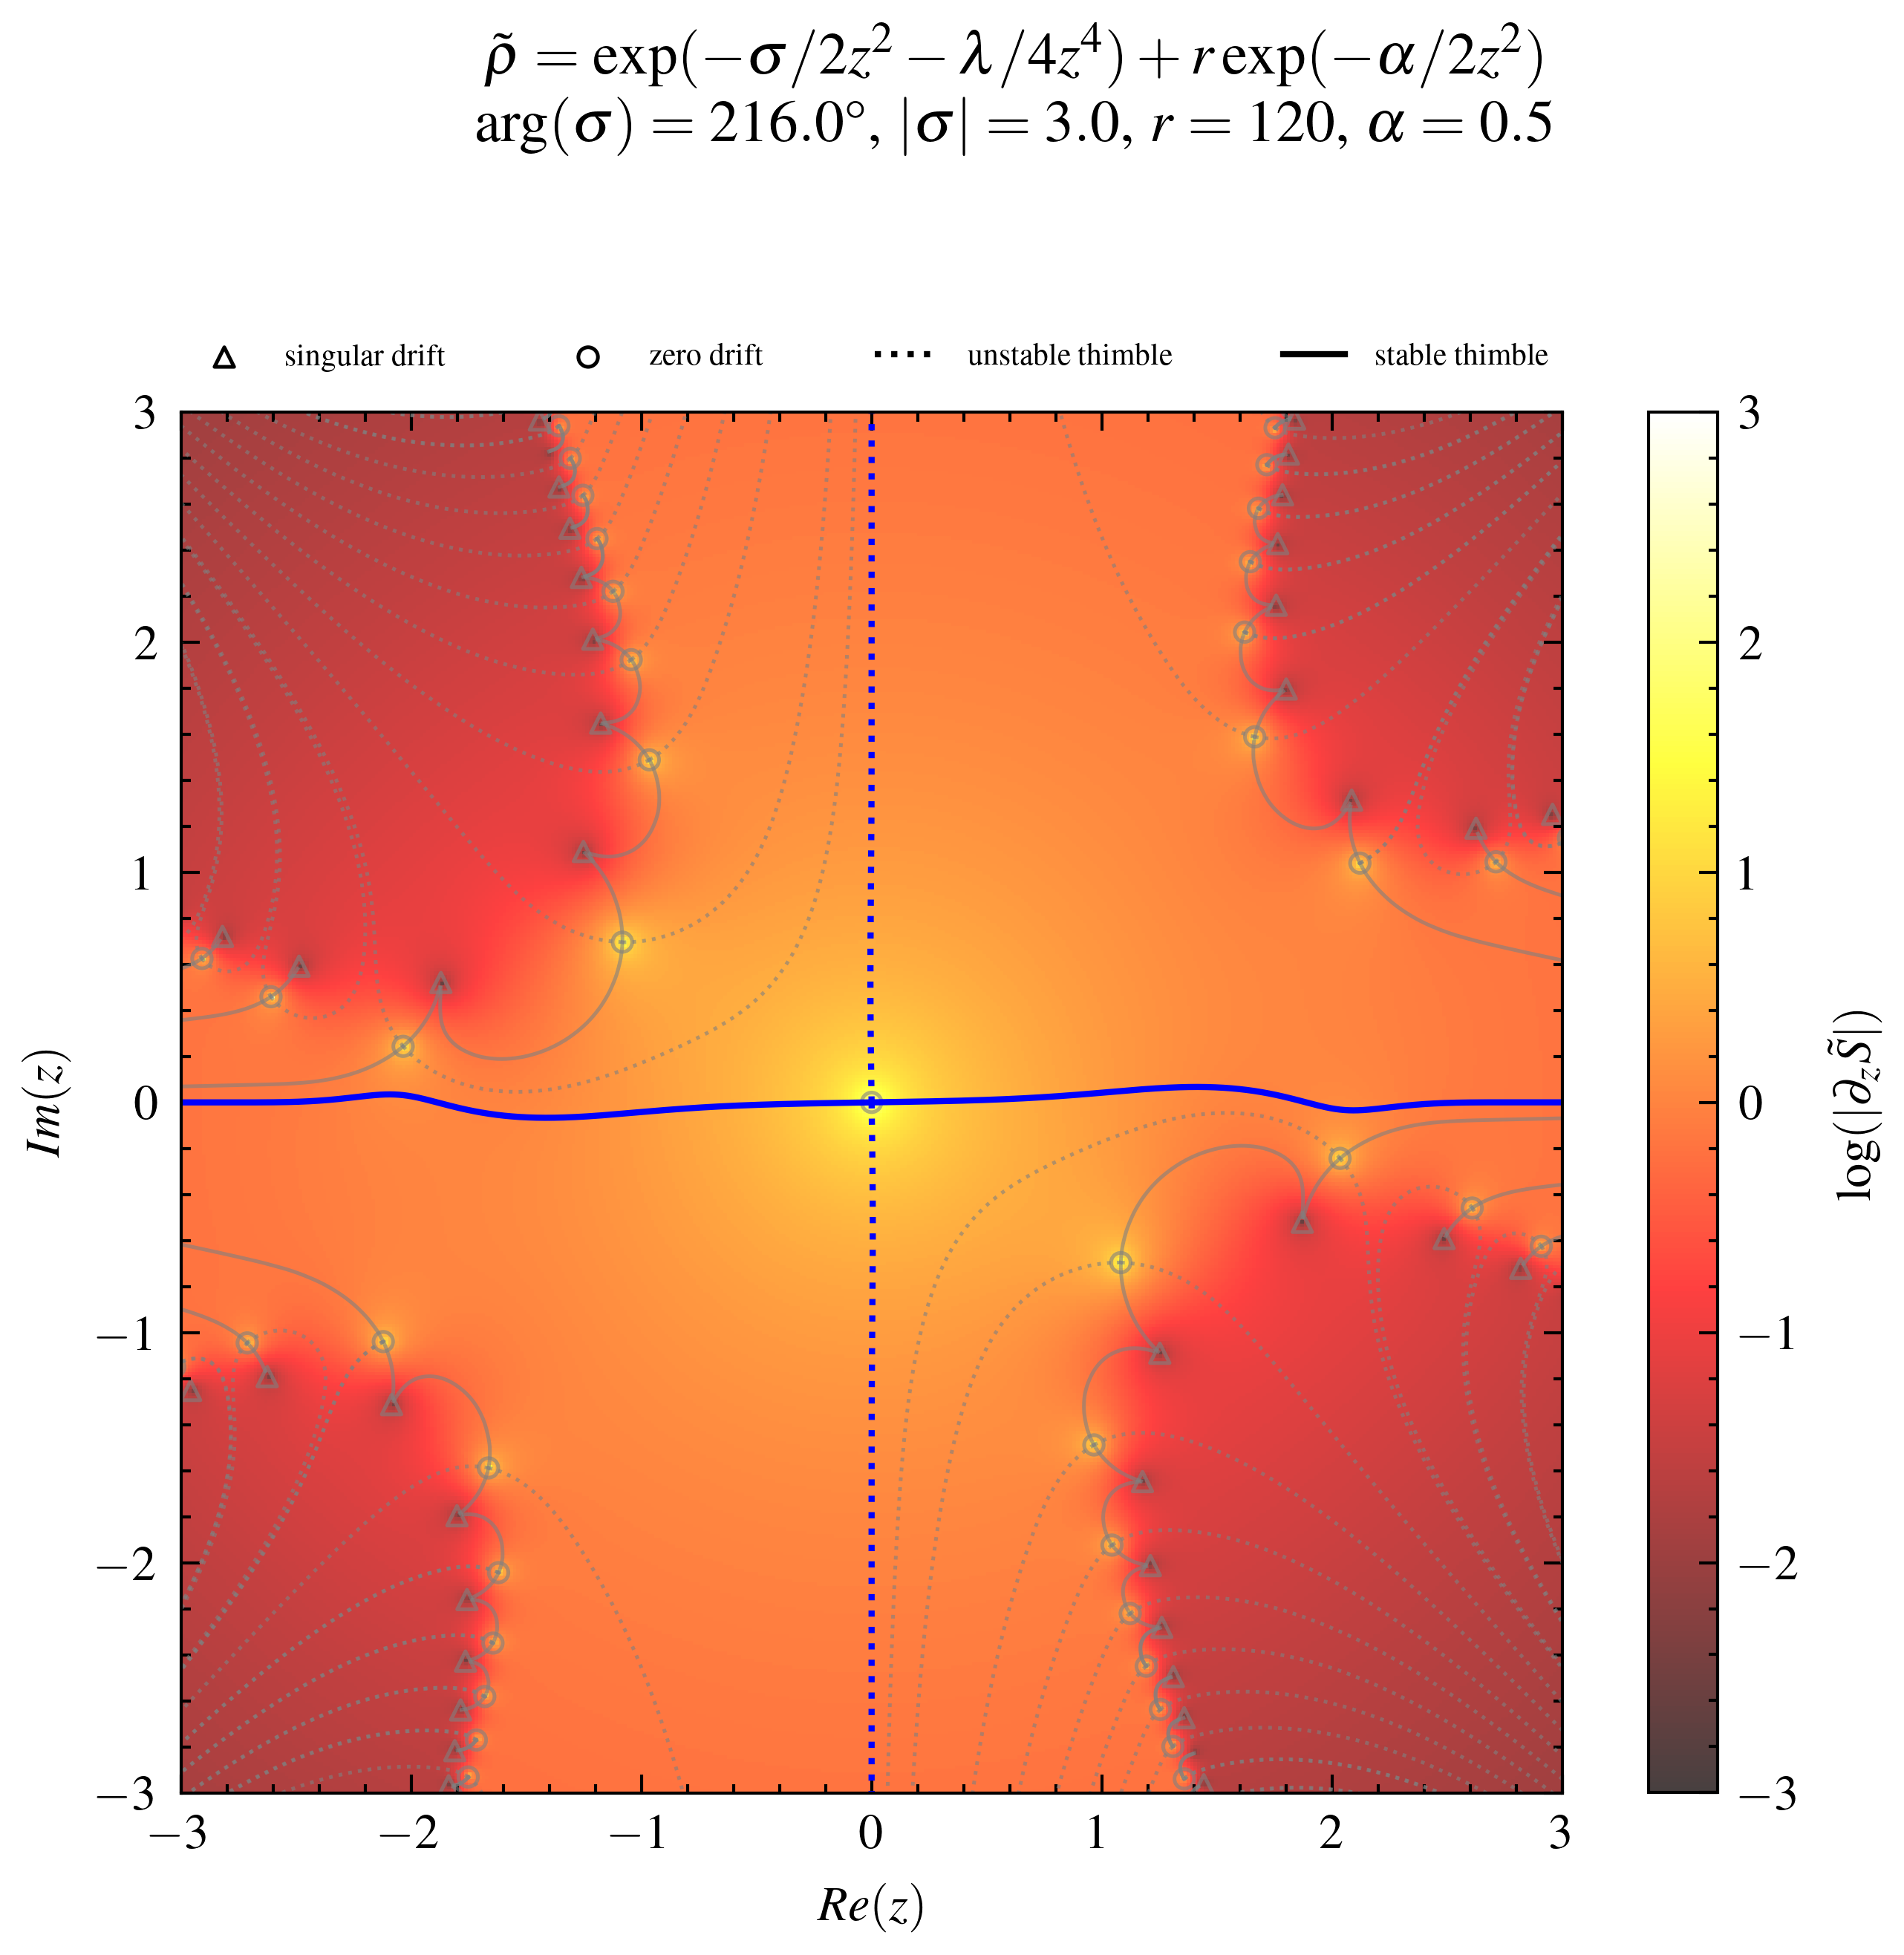

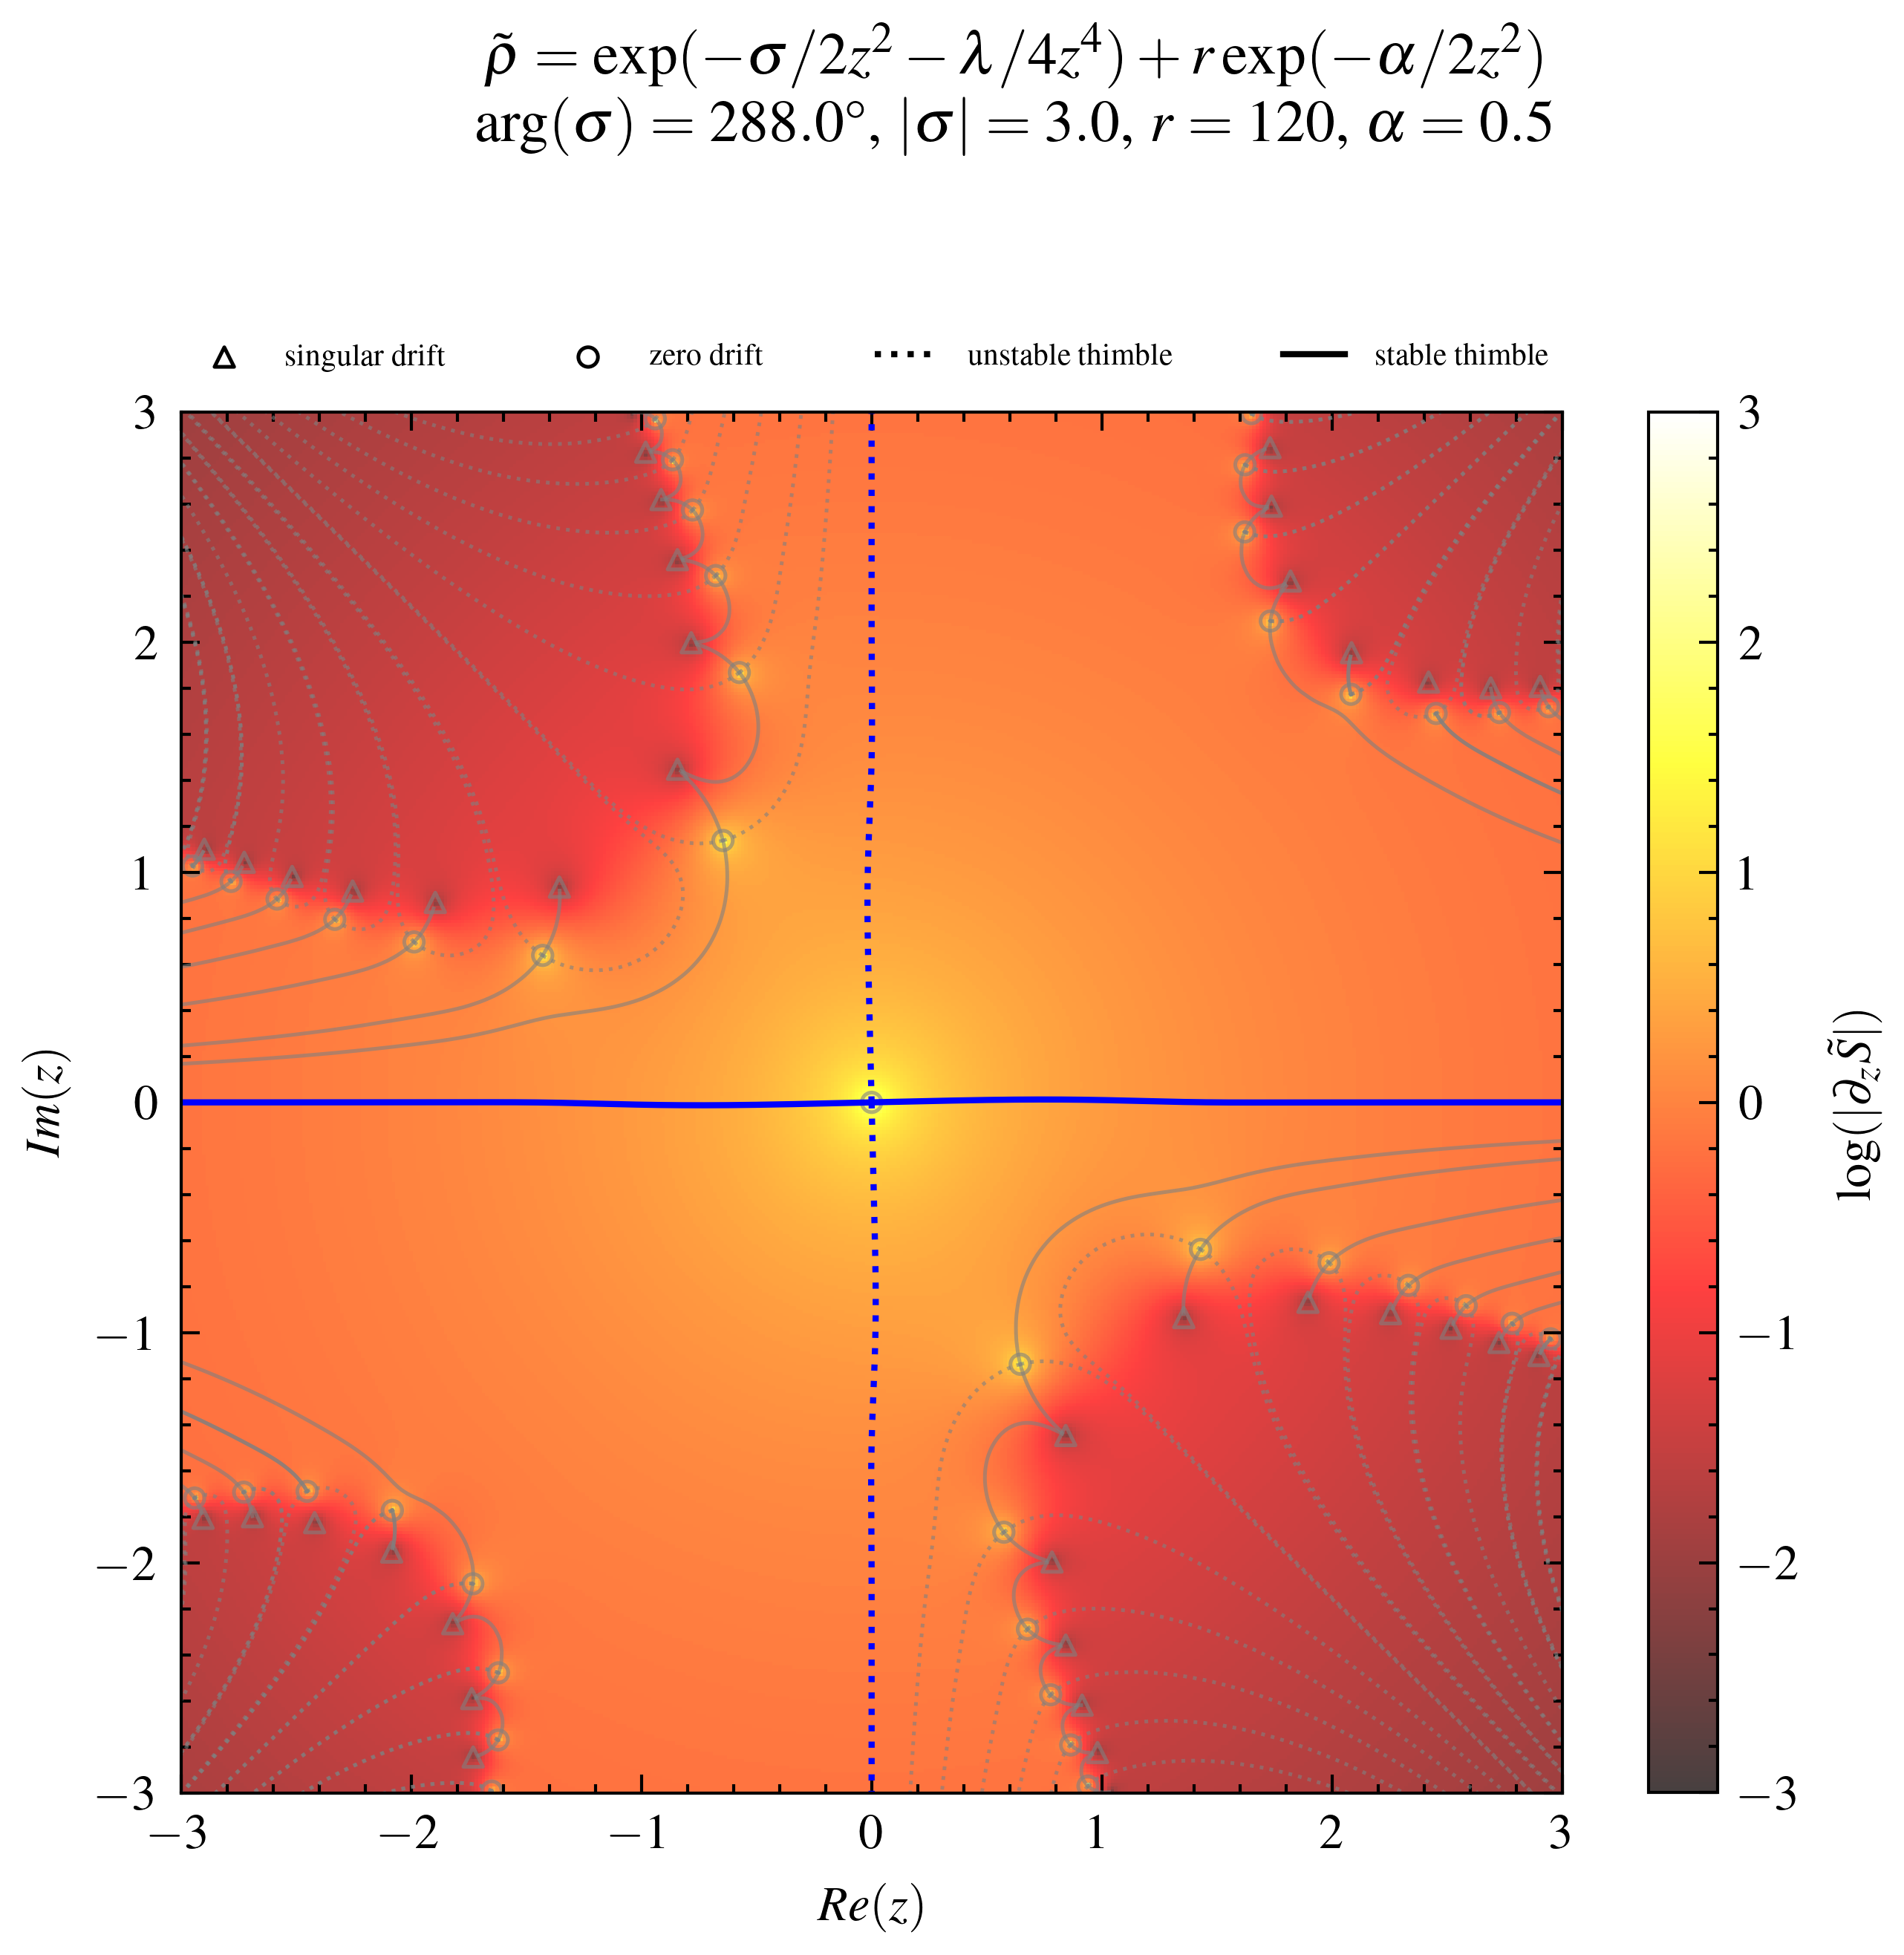

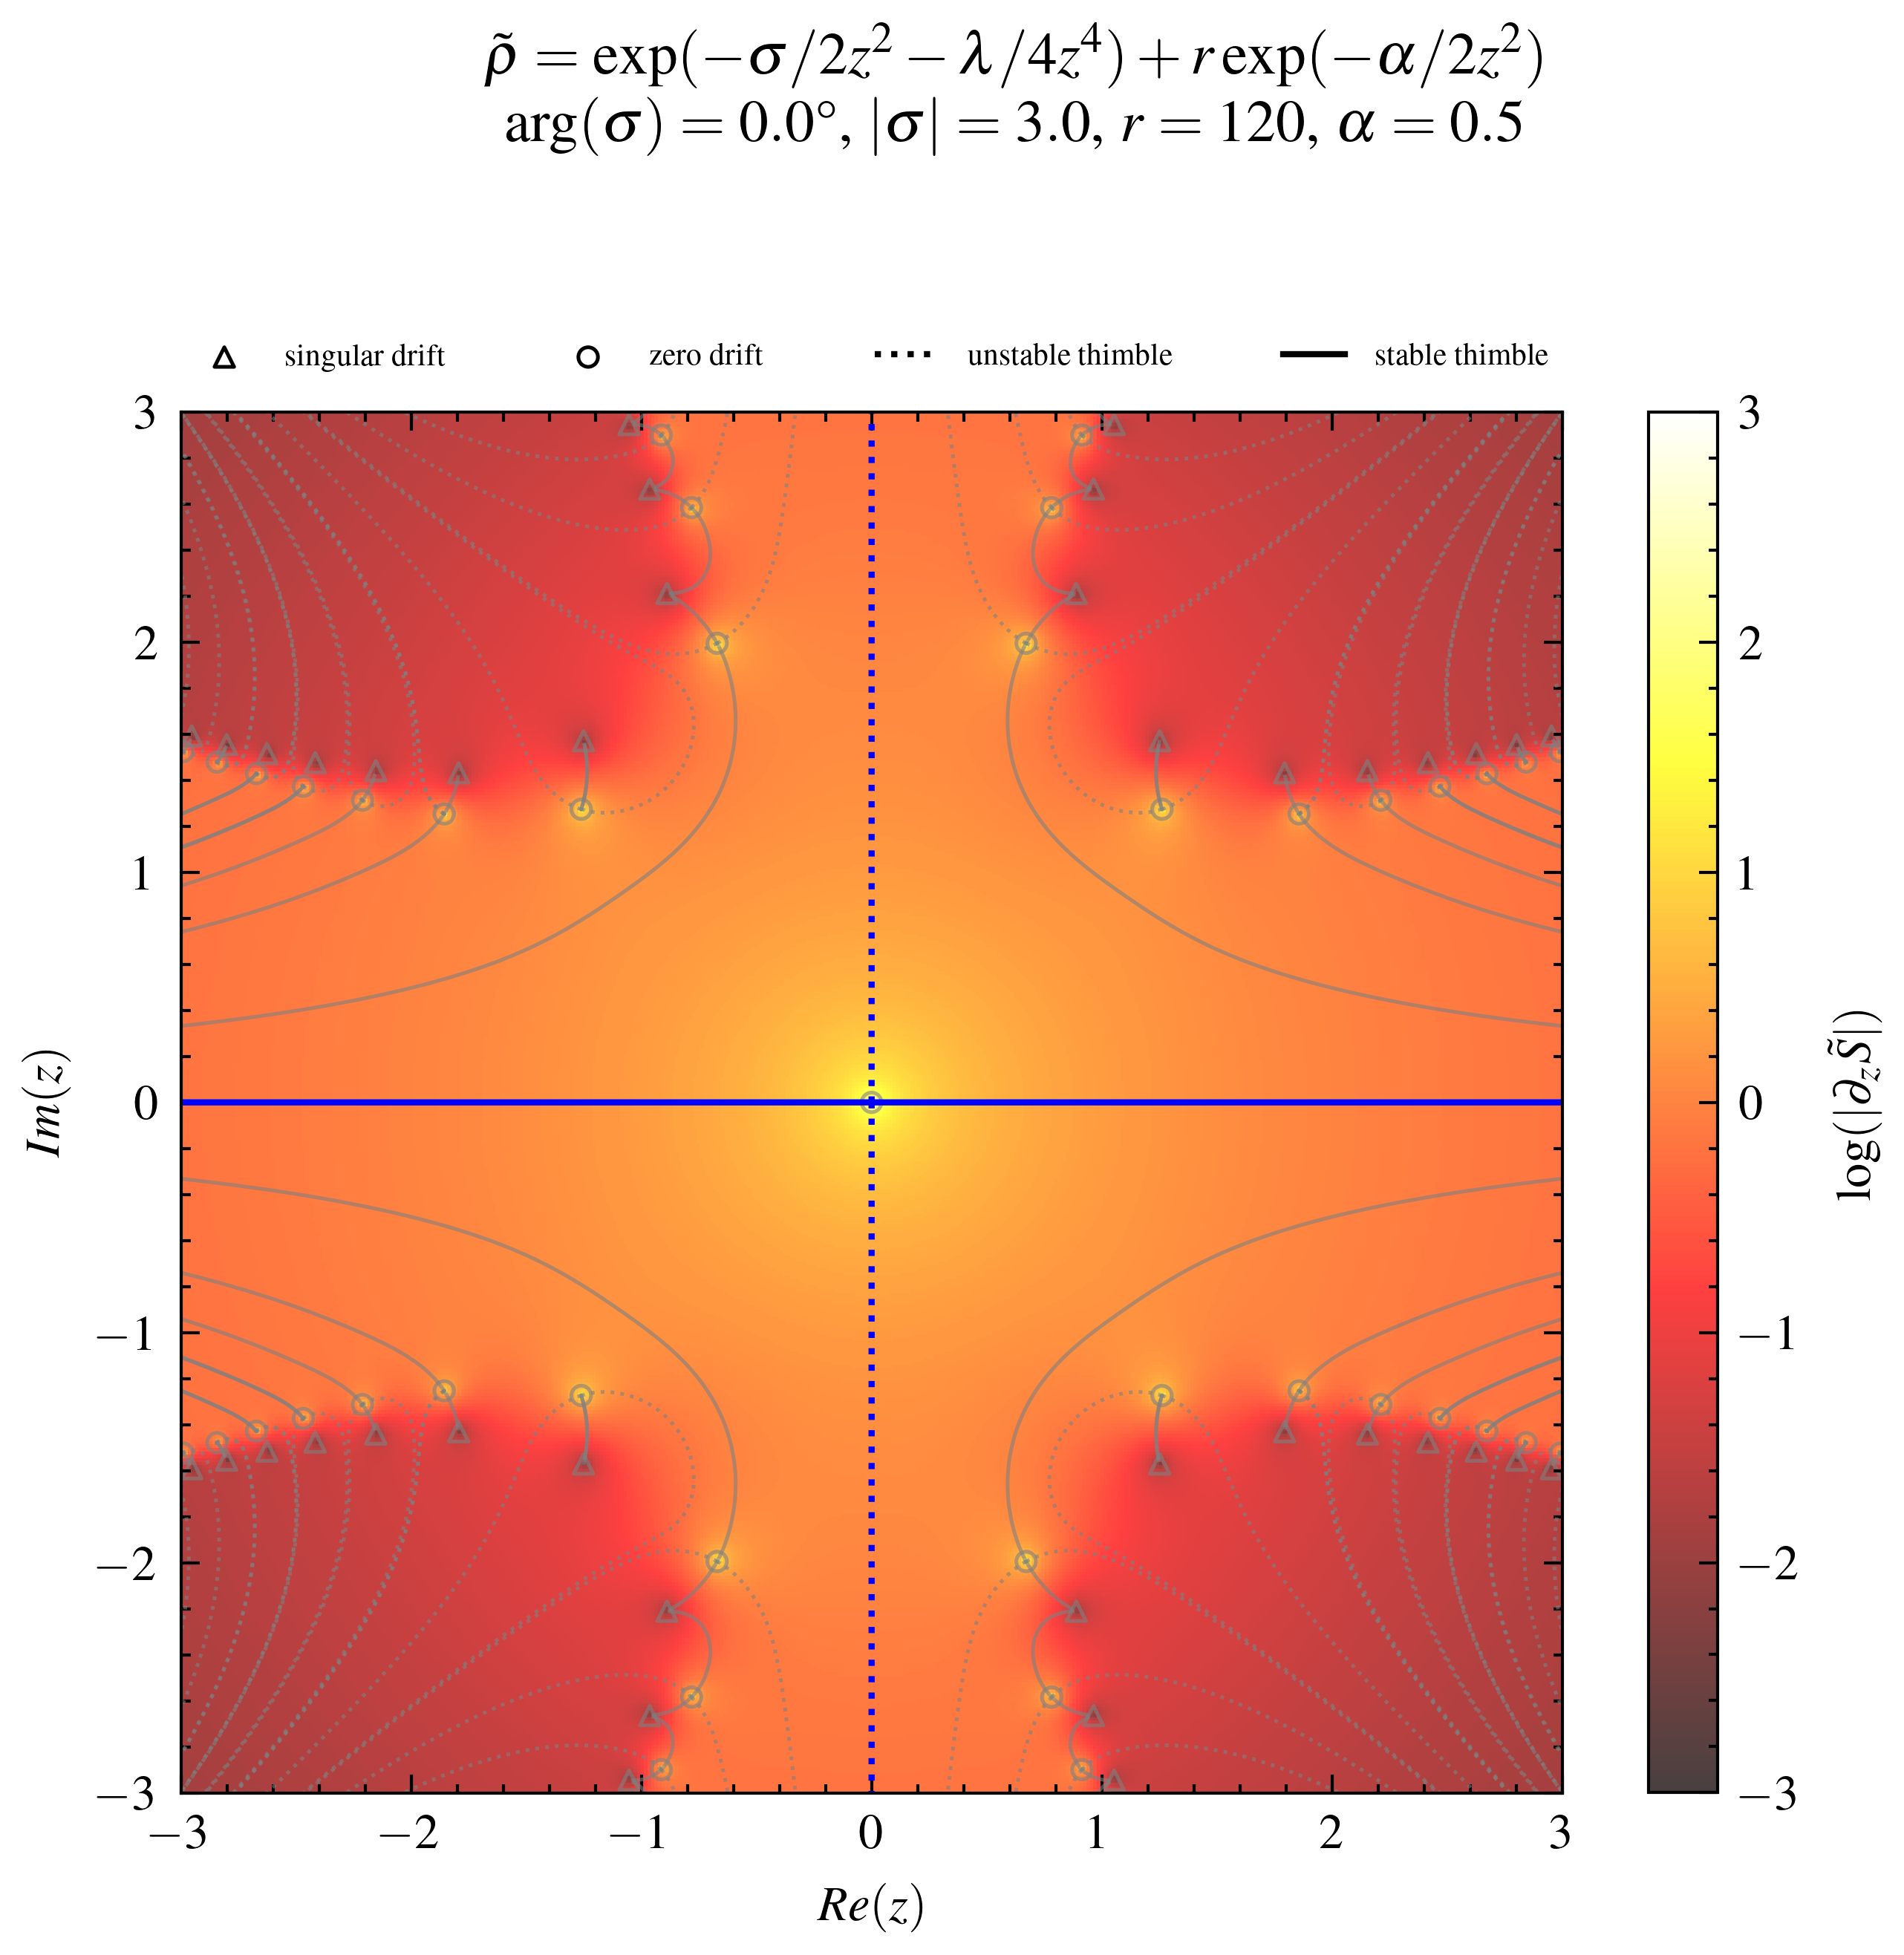

In [5]:


lamb = 1
sigma_abs = 3

start_angle = 0
stop_angle = 2*np.pi

num = 6
angles = np.linspace(start_angle, stop_angle, num)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

mass_modification = 0.5
pullback = 120

import matplotlib.pyplot as plt
from scipy.optimize import root
import scienceplots

plt.style.use(['science', 'ieee'])


def F_real(z_real):
    z = z_real[0] + 1j * z_real[1]
    Fz = F(z)
    return np.array([Fz.real, Fz.imag])

import time

for idx_sig, sigma in enumerate(sigma_vals):
    print(idx_sig)
    t_final = time.time()
    x_range = (-3, 3)
    y_range = (-3, 3)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    deg = np.degrees(np.angle(sigma))
    fig.suptitle(rf"$\tilde{{\rho}} = \exp(-\sigma/2z^2-\lambda/4z^4) + r \exp(-\alpha/2z^2)$"+"\n"\
                 rf"$\text{{arg}}(\sigma) = {{{np.round((deg+360)%360, 3)}}}$°, $|\sigma| = {{{np.round(np.abs(sigma), 3)}}}$, $r={{{np.round(pullback, 3)}}}$"+\
                 rf", $\alpha={{{mass_modification}}}$")

    # mark zeros
    # Define the function whose zeros we want to find
    @np.vectorize
    def F(z):
        action_mod = ((sigma - mass_modification) / 2) * z**2 + (lamb / 4) * np.power(z, 4)
        if np.real(action_mod+np.log(pullback+0j)) > 100:
            return mass_modification * z + ((sigma - mass_modification) * z + lamb * z**3)/pullback * np.exp(-action_mod)
        return mass_modification * z + ((sigma - mass_modification) * z + lamb * z**3) / (1 + pullback * np.exp(action_mod))
    
    x_vals = np.linspace(-5, 5, 50)  # Real part of z
    y_vals = np.linspace(-5, 5, 50)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]

    # Store found roots
    roots = []

    # Solve for each initial guess
    find_roots = 0
    solve_flow = 0
    im_show = 0
    for z0 in initial_guesses:
        t0 = time.time()
        sol = root(F_real, z0, method='hybr')
        find_roots += time.time() - t0

        if sol.success:
            root_found = sol.x[0] + 1j * sol.x[1]

            # Avoid duplicates (consider numerical precision)
            if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):

                roots.append(root_found)
                # stable
                t0 = time.time()
                solutions = solve_floweq(flow_equation_unstable, crit_point=root_found, t_span = (0, 50), t_points=100000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
                solve_flow += time.time() - t0
                
                relevant = False
                conc_sol = np.concatenate(solutions, axis = 0)
                if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True

                for sol in solutions:
                    if relevant:
                        ax.plot(sol.real, sol.imag, color = 'blue', ls = ':')  # Set transparency for better visibility
                    else: 
                        ax.plot(sol.real, sol.imag, color = 'gray', ls = ':', alpha=0.6, lw = 0.6)  # Set transparency for better visibility
    
                # stable
                t0 = time.time()                
                solutions = solve_floweq(flow_equation_stable, crit_point=root_found, t_span = (0, 50), t_points=100000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
                solve_flow += time.time() - t0
                for sol in solutions:
                    if relevant: 
                        ax.plot(sol.real, sol.imag, color = 'blue', ls = "solid")  # Set transparency for better visibility
                    else: 
                        ax.plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        

    roots = np.array(roots)

    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0
    t0 = time.time() 
    im = ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.75, vmin=-3, vmax=3)
    cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.805)
    cbar.ax.set_ylabel(rf'$\log(|\partial_z \tilde{{S}}|)$', rotation=90)
    im_show += time.time() - t0

    # x = np.linspace(*x_range, 35)
    # y = np.linspace(*y_range, 35)
    # X, Y = np.meshgrid(x, y)
    # Z = X + 1j * Y
    # drift_values = np.conj(drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification))
    
    # U = np.real(drift_values)
    # V = np.imag(drift_values)
    # mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    # ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)
    ax.scatter(roots.real, roots.imag, s=10, facecolors='none', edgecolors='gray', lw = 0.6, alpha = 0.6)

    # show singularities in drift
    roots = []
    for z0 in initial_guesses:
        sol = root(lambda x: 1/F_real(x), z0, method='hybr')
        if sol.success:
            root_found = sol.x[0] + 1j * sol.x[1]
            if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
                roots.append(root_found)
    roots = np.array(roots)
    ax.scatter(roots.real, roots.imag, s=10, facecolors='none', edgecolors='gray', marker="^", lw = 0.6, alpha = 0.6)

    ax.set_xlabel(rf"$Re(z)$")
    ax.set_ylabel(rf"$Im(z)$")

    ax.scatter([], [], s=10, facecolors='none', edgecolors='black', marker="^", lw = 0.6, label = "singular drift")
    ax.scatter([], [], s=10, facecolors='none', edgecolors='black', lw = 0.6, label = "zero drift")
    ax.plot([], [], color = 'black', ls = ':', label = "unstable thimble")
    ax.plot([], [], color = 'black', ls = 'solid', label = "stable thimble")

    ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), fontsize = 5, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=1)
    fig.savefig(f"animated_thimbles/gaussian_mod/{idx_sig}")

In [95]:
import numpy as np
from scipy.optimize import root

# Define parameters
alpha = 1.0  # Example value
sigma = 0.454+2.965*1j  # Example value
lambda_ = 1.0  # Example value
r = 10 # Example value

# Define the function and its derivative
def Sigma(z):
    return ((sigma - alpha) / 2) * z**2 + (lambda_ / 4) * z**4

def dSigma_dz(z):
    return (sigma - alpha) * z + lambda_ * z**3

# Define the function whose zeros we want to find
def F(z):
    return alpha * z + dSigma_dz(z) / (1 + r * np.exp(Sigma(z)))

# Convert complex function into a system of real-valued equations
def F_real(z_real):
    z = z_real[0] + 1j * z_real[1]
    Fz = F(z)
    return [Fz.real, Fz.imag]

# Create a grid of initial guesses
x_vals = np.linspace(-2, 2, 10)  # Real part of z
y_vals = np.linspace(-2, 2, 10)  # Imaginary part of z
initial_guesses = [(x, y) for x in x_vals for y in y_vals]

# Store found roots
roots = []

# Solve for each initial guess
for z0 in initial_guesses:
    sol = root(F_real, z0, method='hybr')
    
    if sol.success:
        root_found = sol.x[0] + 1j * sol.x[1]

        # Avoid duplicates (consider numerical precision)
        if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
            roots.append(root_found)

# Print found roots
print("Found roots:")
for root in roots:
    print(root)

Found roots:
0j
(-1.5315096890063606-0.27518940164203043j)
(0.4145061566754722+0.9303880053717283j)
(-0.41450615667549057-0.9303880053717406j)
(-0.6556363125784588-2.1912482991881483j)
(-0.5094531619113655-1.7738647463973287j)
(0.5094531619122701+1.7738647463966475j)
(0.6556363125784588+2.1912482991881483j)
(1.5315096890063606+0.2751894016420304j)


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_22826/718073184.py:58: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_22826/718073184.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


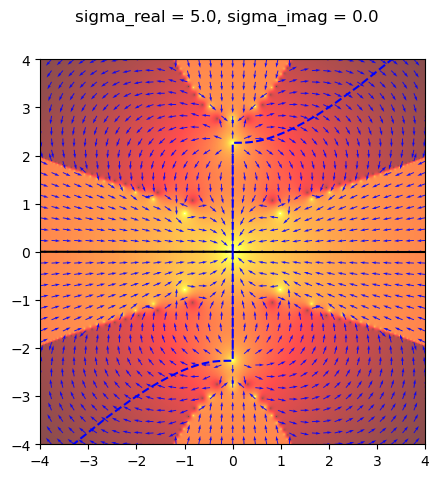

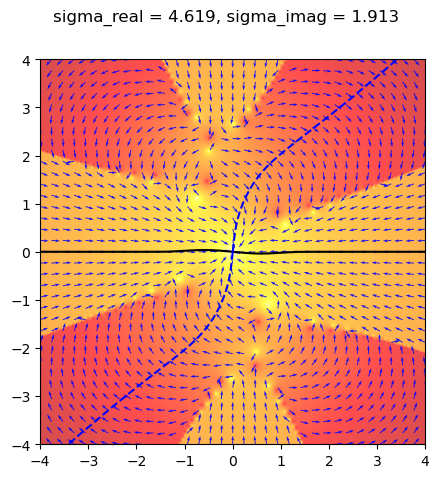

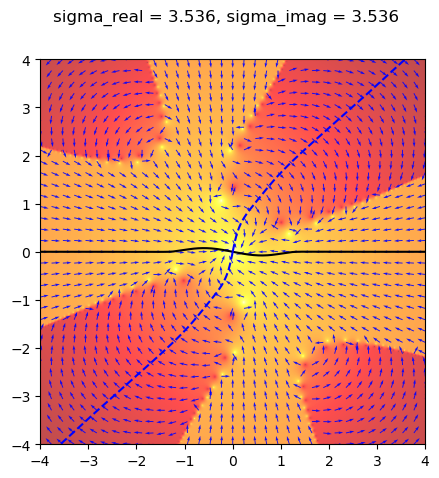

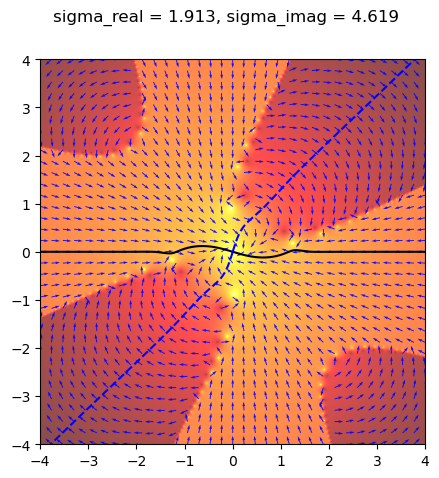

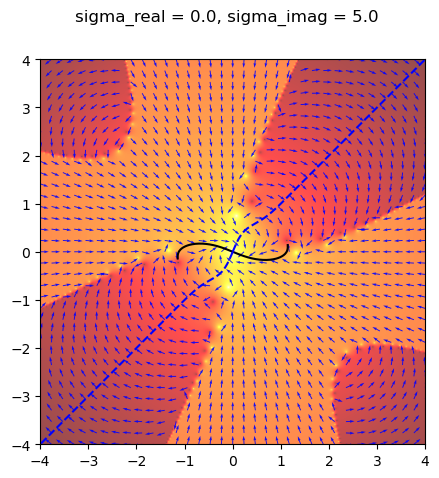

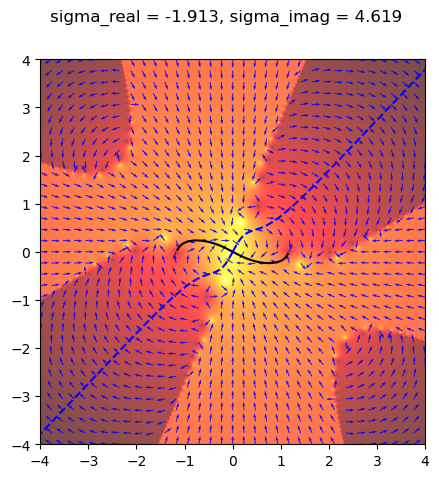

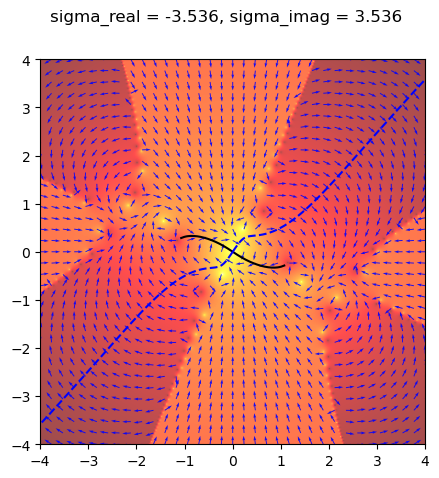

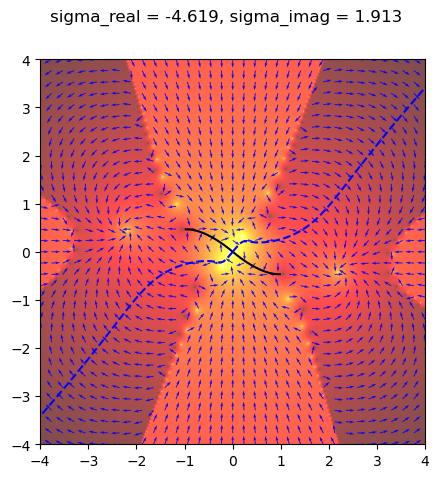

In [148]:
lamb = 1
sigma_abs = 5

start_angle = 0
stop_angle = np.pi

num = 8
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

mass_modification = 1
pullback = 5

import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'blue', ls = '--')  # Set transparency for better visibility

    x_range = (-4, 4)
    y_range = (-4, 4)

    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)
    fig.show()

In [ ]:
for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 100), t_points=10000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'blue', ls = '--')  # Set transparency for better visibility

    x_range = (-4, 4)
    y_range = (-4, 4)

    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)
    fig.show()

    ax.set_title(label)

    ax.set_xlim(-10,10)
    ax.set_ylim(-10,10)



TypeError: drift_func() got an unexpected keyword argument 'phi_singular'

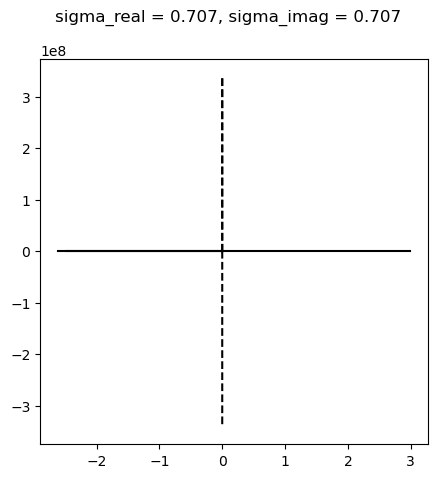

In [53]:


lamb = 1
sigma_abs = 1

start_angle = np.pi/4
stop_angle = np.pi

num = 4
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

phi_singular = 2
pullback = 2



import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 80000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility
    # y_range = ax.get_ylim()

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 80000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black', ls = '--')  # Set transparency for better visibility

    x_range = (-3, 3)
    y_range = (-3, 3)
    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    fig.show()
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)

We want to artificially introduce zeros in the density by a additive modification of the action. 
$$
S \to \tilde{S} = \frac{\sigma}{2}z^2+\frac{\lambda}{4}z^4+\psi(z)\qquad \rho \to \tilde{\rho} = \rho + R(z)
$$
forcing $\tilde{\rho} = \tilde{S}$ gives
$$
\psi(z) = -\ln(1+R(z)e^{S})
$$

As an example, we want to generate a zero in $\tilde{\rho}$ at a finite $z = z_{0}$. 
This is achieved by setting $R(z) = -\rho(z_{0})$ resulting in 
$$
\psi(z) = -\ln\left( 1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right) \right)
$$
The drift is calculated
$$
\partial_{z}\tilde{S} = \partial_{z}S+\partial_{z}\psi= \partial_{z}S+\frac{\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}{1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}\partial_{z}S= \partial_{z}S\, \left[ 1+\frac{\exp{\{S(z)-S(z_{0})\}}}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$
Further simplifying
$$
\partial_{z}\tilde{S} = \partial_{z}S \, \left[ \frac{1}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$

In [37]:
from sympy import symbols, diff, Function, re, im, sqrt, exp, I
import sympy as sp
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = -exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))

drift_mod = sp.diff(action_mod, z).simplify()
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 + sigma)*exp(z_0**2*(lambda*z_0**2/2 + sigma))/(exp(z_0**2*(lambda*z_0**2/2 + sigma)) - exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2))

In [38]:
def action_mod_func(z, z0, r, sigma, lamb):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    out = action

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if overflow:
        out -= 1j*np.pi + delta_s
    else:
        out -= np.log(1-np.exp(delta_s))
    return out

action_mod_func = np.vectorize(action_mod_func)

In [39]:
def drift_mod_func(z, z0, r, sigma, lamb):
    drift = lamb * z**3 + sigma * z
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if delta_s == 0: return np.inf
    if overflow:
        out = -drift*np.exp(-delta_s)
    else:
        out = drift / (1-np.exp(delta_s))
    return out

drift_mod_func = np.vectorize(drift_mod_func)


Let's look at the modification 
$$
R(z) = r(z^2-z_0^2)-\rho(-S_0)
$$

In [41]:
from sympy import symbols, diff, Function, re, im, sqrt, exp
import sympy as sp
sigma_r, lamb_r = symbols('sigma_r, lambda_r', real=True)
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi', real=True)
sigma, lamb = sigma_r*exp(sp.I*sigma_phi), lamb_r*exp(sp.I*lamb_phi)
z_phi, z_r = symbols('z_phi, z_r', real=True)
z = z_r*exp(sp.I*z_phi)
z = symbols('z')
# sigma, lamb = symbols('sigma lambda')
action = sigma/2*z**2 + lamb/4*z**4

In [42]:
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = r*(z**2-z_0**2)-exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))
action_mod_func = sp.lambdify((z, z_0, sigma, lamb, r), action_mod, 'numpy')

drift_mod = sp.diff(action_mod, z).simplify()
drift_mod_func  = sp.lambdify((symbols('t z z_0 sigma lambda r')), drift_mod,  'numpy')
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 - 2*r*exp(lambda*z**4/4 + sigma*z**2/2) + sigma)*exp(lambda*z_0**4/4 + sigma*z_0**2/2)/(r*z**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - r*z_0**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - exp(lambda*z**4/4 + sigma*z**2/2) + exp(lambda*z_0**4/4 + sigma*z_0**2/2))

In [ ]:
import sympy as sp
from sympy import exp, I

# Define time variable
t = sp.Symbol('t', real=True)

# Define complex parameters in polar form
z_r, z_phi = sp.symbols('z_r z_phi', real=True)
sigma_r, sigma_phi = sp.symbols('sigma_r sigma_phi', real=True)
lambda_r, lambda_phi = sp.symbols('lambda_r lambda_phi', real=True)
r_r, r_phi = sp.symbols('r_r r_phi', real=True)
alpha = sp.Symbol('alpha', real=True)

# Define complex variables
sigma = sigma_r * exp(I * sigma_phi)
lambda_ = lambda_r * exp(I * lambda_phi)
r = r_r * exp(I * r_phi)
z = z_r*exp(I*z_phi)

d= sigma*z+lambda_*z**3-(r*exp((sigma-alpha)*z**2/2+lambda_*z**4/4)*((sigma-alpha)*z+lambda_*z**3)) /(1+r*exp((sigma-alpha)*z*2/2+lambda_*z**4/4))
(sp.re(d)).simplify()


z_r*(lambda_r*z_r**2*cos(lambda_phi + 3*z_phi) + r_r*(-alpha*sin(z_phi) + lambda_r*z_r**2*sin(lambda_phi + 3*z_phi) + sigma_r*sin(sigma_phi + z_phi))*im(exp(lambda_r*z_r**4*exp(I*(lambda_phi + 4*z_phi))/4 + I*r_phi - z_r**2*(alpha - sigma_r*exp(I*sigma_phi))*exp(2*I*z_phi)/2)/(r_r*exp(I*r_phi + z_r*(-4*alpha + lambda_r*z_r**3*exp(I*(lambda_phi + 3*z_phi)) + 4*sigma_r*exp(I*sigma_phi))*exp(I*z_phi)/4) + 1)) + r_r*(alpha*cos(z_phi) - lambda_r*z_r**2*cos(lambda_phi + 3*z_phi) - sigma_r*cos(sigma_phi + z_phi))*re(exp(lambda_r*z_r**4*exp(I*(lambda_phi + 4*z_phi))/4 + I*r_phi - z_r**2*(alpha - sigma_r*exp(I*sigma_phi))*exp(2*I*z_phi)/2)/(r_r*exp(I*r_phi + z_r*(-4*alpha + lambda_r*z_r**3*exp(I*(lambda_phi + 3*z_phi)) + 4*sigma_r*exp(I*sigma_phi))*exp(I*z_phi)/4) + 1)) + sigma_r*cos(sigma_phi + z_phi))